In [8]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Flatten, Dense, Dropout
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from ucimlrepo import fetch_ucirepo
import matplotlib.pyplot as plt

In [ ]:
# Cargar el dataset de consumo eléctrico de Tetuán
tetuan = fetch_ucirepo(id=849)
x = tetuan.data.features.copy()
y = tetuan.data.targets.copy()

# Armar un único dataframe con features + target (sumatoria de las 3 zonas = consumo total)
df = x.copy()
df['PowerConsumption'] = y.sum(axis=1).values

# Ordenar por fecha y extraer hora del día
df['DateTime'] = pd.to_datetime(df['DateTime'])
df = df.sort_values('DateTime').reset_index(drop=True)
df['hour'] = df['DateTime'].dt.hour
df = df.drop(columns=['DateTime'])

target = df['PowerConsumption'].values.astype(np.float32)
features = df.drop(columns=['PowerConsumption']).values.astype(np.float32)

# Escalar
x_scaler = StandardScaler()
features_sc = x_scaler.fit_transform(features).astype(np.float32)

y_scaler = StandardScaler()
target_sc = y_scaler.fit_transform(target.reshape(-1, 1)).ravel().astype(np.float32)

# Crear secuencias para predecir el siguiente valor
sequence_length = 24
X, y_seq = [], []
for i in range(len(features_sc) - sequence_length):
    X.append(features_sc[i:i+sequence_length])
    y_seq.append(target_sc[i+sequence_length])
X = np.array(X)
y_seq = np.array(y_seq)

# División entrenamiento/prueba (80/20)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

In [11]:
# Definir el modelo de la red neuronal convolucional de 1D para regresión
model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(sequence_length, X_train.shape[2])),  # Capa convolucional 1D con 32 filtros
    MaxPooling1D(2),  # Capa de MaxPooling 1D
    Conv1D(64, 3, activation='relu'),  # Segunda capa convolucional 1D con 64 filtros
    MaxPooling1D(2),  # Segunda capa de MaxPooling 1D
    Flatten(),  # Aplanar la salida para la capa completamente conectada
    Dense(64, activation='relu'),  # Capa totalmente conectada con 64 neuronas
    Dropout(0.5),  # Dropout para reducir el sobreajuste
    Dense(1)  # Capa de salida con una sola neurona para la regresión (valor continuo)
])

# Compilar el modelo
model.compile(optimizer='adam',
              loss='mean_squared_error')  # Pérdida MSE para problemas de regresión

# Entrenar el modelo
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_data=(X_test, y_test), verbose=1)


Epoch 1/20


c:\Users\valer\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.3204 - val_loss: 0.0957
Epoch 2/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1941 - val_loss: 0.0767
Epoch 3/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1771 - val_loss: 0.1308
Epoch 4/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1606 - val_loss: 0.1307
Epoch 5/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1568 - val_loss: 0.0965
Epoch 6/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1503 - val_loss: 0.1118
Epoch 7/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1468 - val_loss: 0.1338
Epoch 8/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1420 - val_loss: 0.1261
Epoch 9/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1352 - val_loss: 0.1305
Epoch 10/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1356 - val_loss: 0.1385
Epoch 11/20
1310/1310 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - loss: 0.1301 - val_loss: 0.1237
Epoch 12/20
1310/1310 ━━━━━━━━━━━━━━━━━━━

Pérdida en el conjunto de prueba (MSE devuelto por Keras): 0.1423
328/328 ━━━━━━━━━━━━━━━━━━━━ 0s 949us/step
Mean Squared Error (MSE): 41809452.0000
Mean Absolute Error (MAE): 5354.2100
R2 Score: 0.7901


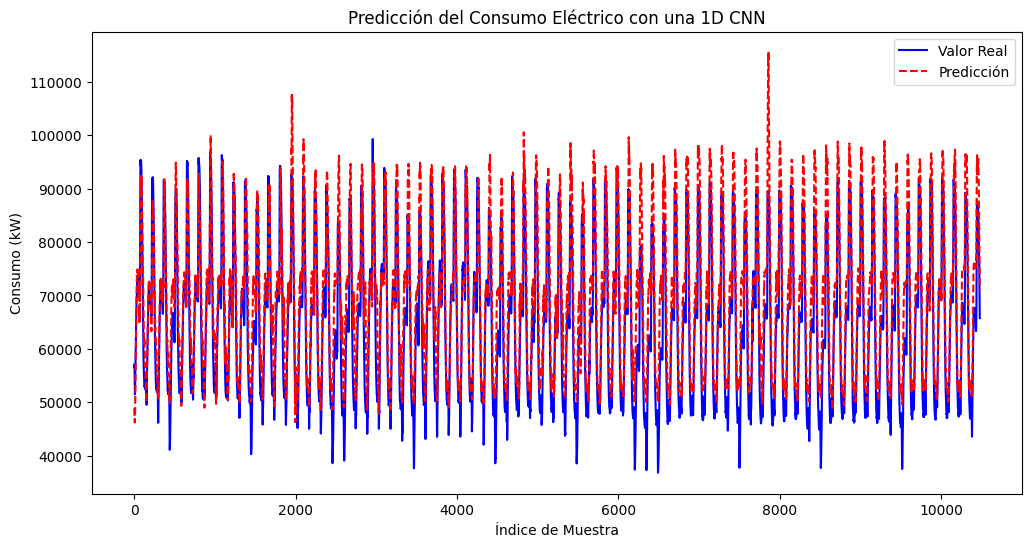

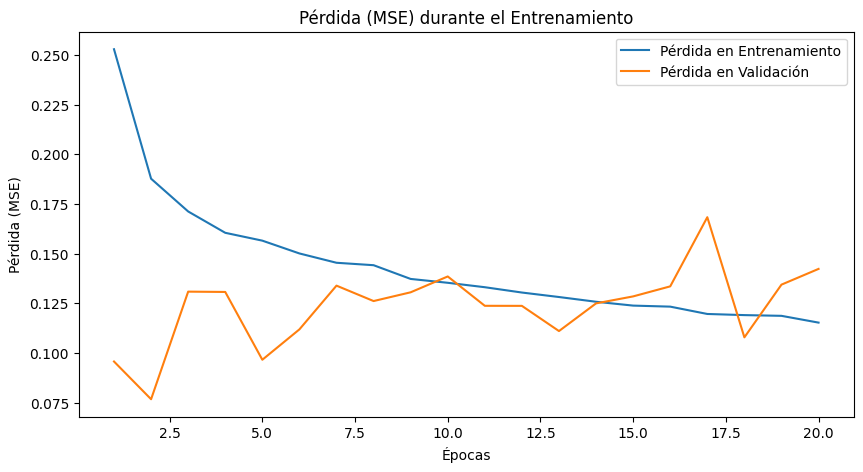

In [ ]:

# Evaluar el modelo en el conjunto de prueba
test_loss = model.evaluate(X_test, y_test, verbose=0)
print(f"Pérdida en el conjunto de prueba (MSE devuelto por Keras): {test_loss:.4f}")

# Realizar predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Desescalar para obtener las métricas en la escala real (kW)
y_test_real = y_scaler.inverse_transform(y_test.reshape(-1, 1)).ravel()
y_pred_real = y_scaler.inverse_transform(y_pred).ravel()

# Métricas adicionales
mse = mean_squared_error(y_test_real, y_pred_real)
mae = mean_absolute_error(y_test_real, y_pred_real)
r2 = r2_score(y_test_real, y_pred_real)
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

# Graficar los valores reales vs los valores predichos
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test_real)), y_test_real, label='Valor Real', color='blue')
plt.plot(range(len(y_pred_real)), y_pred_real, label='Predicción', color='red', linestyle='--')
plt.title('Predicción del Consumo Eléctrico con una 1D CNN')
plt.xlabel('Índice de Muestra')
plt.ylabel('Consumo (kW)')
plt.legend()
plt.show()

# Graficar la pérdida durante el entrenamiento
epochs = range(1, len(history.history['loss']) + 1)
plt.figure(figsize=(10, 5))
plt.plot(epochs, history.history['loss'], label='Pérdida en Entrenamiento')
plt.plot(epochs, history.history['val_loss'], label='Pérdida en Validación')
plt.title('Pérdida (MSE) durante el Entrenamiento')
plt.xlabel('Épocas')
plt.ylabel('Pérdida (MSE)')
plt.legend()
plt.show()